## <p style="text-align: right;"> &#9989; Put your name here</p>

# CMSE 201: Practice for using `polyfit()` and `curve_fit()`

Includes practice for:
- load basic data
- numpy arrays
- fitting

Goal: Help students prepare for quiz 4b


### How many births in the US?

The following dataset was used as the basis for the story [Some People Are Too Superstitious To Have A Baby On Friday The 13th](https://fivethirtyeight.com/features/some-people-are-too-superstitious-to-have-a-baby-on-friday-the-13th/) and is available at [Fivethirtyeight](https://github.com/fivethirtyeight/data)  (a great resource for your semester project data).

&#9989;&nbsp; Load the data from `US_births_2000-2014_SSA.csv` into your notebook **using Pandas** and then use Pandas to display the first 10 rows of the data.

In [2]:
import pandas as pd

df = pd.read_csv("US_births_2000-2014_SSA.csv")
df.head(10)

,year,month,date_of_month,day_of_week,births
0,2000,1,1,6,9083
1,2000,1,2,7,8006
2,2000,1,3,1,11363
3,2000,1,4,2,13032
4,2000,1,5,3,12558
5,2000,1,6,4,12466
6,2000,1,7,5,12516
7,2000,1,8,6,8934
8,2000,1,9,7,7949
9,2000,1,10,1,11668


&#9989;&nbsp; Let's try to answer the question:

**PART 1: Did the number of births increase during the year 2000?** (In other words, as the year 2000 progressed, were there more births at the end of the year compared to the beginning (on average))

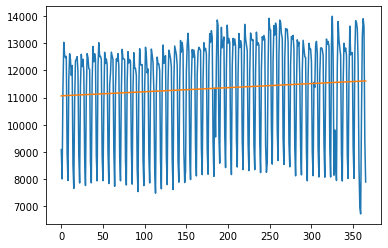

[1.50101300e+00 1.10637646e+04]


In [4]:
# Make a plot of the number of births versus day for just the year 2000
import matplotlib.pyplot as plt
import numpy as np

df_2000 = df[df["year"] == 2000]



# Fit a model (polynomial or arbitrary curve) to this data
fit_vals = np.polyfit(df_2000.index, df_2000["births"],1)
fit_func = np.poly1d(fit_vals)
y_fit = fit_func(df_2000.index)



# Display original data and fitted model
plt.plot(df_2000.index, df_2000["births"])
plt.plot(df_2000.index, y_fit)
plt.show()


# What is the equation of the fitted model?

print(fit_vals)

# Make a conclusion about how the births have changed throughout the year

&#9989;&nbsp; Let's try to answer the question:

**PART 2: what is a good function that fits the number of births in January 2000?** 

[-2.27586298e+03  1.43625730e-01  1.10537700e+04]


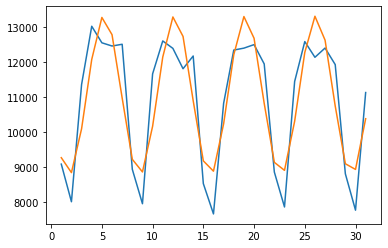

In [25]:
# Make a plot of the number of births versus day for just January 2000
# b2 = bb[bb['year']==2000]
# b2Jan = b2[b2['month']==1]  # b2Jan is a pandas dataframe of just Jan 2000

from scipy.optimize import curve_fit

df_2000_Jan = df_2000[df_2000['month']==1]  # b2Jan is a pandas dataframe of just Jan 2000

# plt.plot(df_2000_Jan["date_of_month"], df_2000_Jan["births"])
# plt.show()

# Fit the following arbitrary function to the births in jan 2000
def sin1(x,A,B,C):
    y1 = A*np.sin(B*x*2*np.pi)+C
    return y1

# popt, pcov = curve_fit(sin1, df_2000_Jan["date_of_month"], df_2000_Jan["births"])
popt, pcov = curve_fit(sin1, df_2000_Jan["date_of_month"], df_2000_Jan["births"],p0=[-1000,0.127,10000])
print(popt)



# If trouble fitting data, try initializing with A = -4000; B = 1/7; C = 9000

# popt, pcov = curve_fit(sin1, df_2000_Jan["date_of_month"], df_2000_Jan["births"],p0=[-4000,(1/7.0),9000])
# print(popt)


# Display original data and fitted model
y_fit_sin1 = sin1(df_2000_Jan["date_of_month"],*popt)

plt.plot(df_2000_Jan["date_of_month"], df_2000_Jan["births"])
plt.plot(df_2000_Jan["date_of_month"], y_fit_sin1)
plt.show()

# What is the equation of the fitted model? (Write out the equation)



# Make a conclusion about how the births have changed in january 2000

----------------
&#9989;&nbsp; Let's try to answer the question:

**PART 3: Based on all of the data from 2000-2014, predict the number of births on April 23, 2021 (the last day of this semester) ?  And, predict the total number of births in the year 2021?** 

10932.966243191573


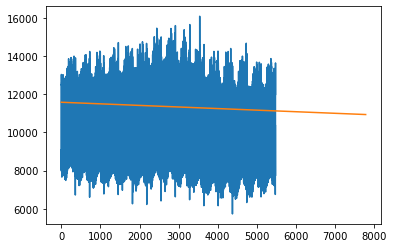

In [26]:

#The year 2000 is day 0
#The last day is April 23, 2021


x = df.index
y = df["births"]
x_max = 7783
x_fit = np.arange(0,x_max)

fit_vals_full = np.polyfit(x, y, 1)
fit_func_full = np.poly1d(fit_vals_full)
y_fit_full = fit_func_full(x_fit)
print(fit_func_full(x_max))

plt.plot(x, y)
plt.plot(x_fit, y_fit_full)
plt.show()

In [28]:
x_2021 = [7671,7671+365]
x_2021_vals = np.arange(x_2021[0],x_2021[1])
year_2021_total = np.sum(fit_func_full(x_2021_vals))
print(year_2021_total/1.0e6)

3.988419880084197


[ 7.26974180e-02 -4.37672053e+02  5.85501106e+05  1.17539272e+09
 -3.53787202e+12  2.36659981e+15]


/Users/cmse/opt/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3343: RankWarning: Polyfit may be poorly conditioned
  exec(code_obj, self.user_global_ns, self.user_ns)


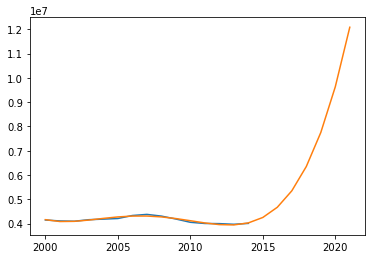

In [44]:
# x_2000s = np.arange(0,7671+365,365)
# x_2000s = np.arange(0,np.amax(),365)
y_yearly_sums = []
years = np.unique(df["year"])
# print( np.unique(df["year"]))

for year in years:
    temp_births = np.sum(df[df["year"] == year]["births"])
    y_yearly_sums.append(temp_births)
    

x_fit_by_year = np.arange(2000,2022)
fit_vals_by_year = np.polyfit(years,y_yearly_sums , 5)
fit_func_by_year = np.poly1d(fit_vals_by_year)
y_fit_by_year = fit_func_by_year(x_fit_by_year)
# y_fit_by_year = fit_func_by_year(years)
print(fit_vals_by_year)

plt.plot(years, y_yearly_sums)
plt.plot(x_fit_by_year, y_fit_by_year)
# plt.plot(years, y_fit_by_year)
plt.show()




# print(x_2000s)
# print(np.arange(0,np.amax(df.index)+1,365))
# print(np.amax(df.index))
# for end_date in np.arange(0,np.amax(df.index),365):
#     temp_year_total = np.sum(y[])
    



&#169; Copyright 2021,  Michigan State University Board of Trustees